# DXY Signal Evaluation — Aug 2025 → Mar 2026
**Excludes Apr/May 2025** (out-of-sample period not intended for evaluation)

Three angles:
1. **Volatility signal** — does flagging high criticality identify larger DXY moves?
2. **Directional accuracy** — can the model predict direction on its best-defined slice?
3. **Monthly stability** — is performance consistent over time?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

TEAL   = '#1D9E75'
CORAL  = '#D85A30'
GRAY   = '#888780'
BLUE   = '#378ADD'
AMBER  = '#BA7517'

# ── Load & filter ────────────────────────────────────────────────────────
df_raw = pd.read_csv('data/results_aug_mar_mapped.csv')
df_raw['dt'] = pd.to_datetime(df_raw['article_published_utc'], utc=True, errors='coerce')

# Exclude Apr and May 2025
apr_may = (df_raw['dt'].dt.year == 2025) & (df_raw['dt'].dt.month.isin([3, 4, 5]))
df = df_raw[~apr_may].copy()

relevant = df[df['is_relevant'] == True].copy()
critical = df[df['is_critical'] == True].copy()
not_high = df[df['criticality_level'] == 'not high'].copy()

HORIZONS = ['pct_5m', 'pct_15m', 'pct_1h', 'pct_4h', 'pct_1d']
H_LABELS = ['5m', '15m', '1h', '4h', '1d']
sd = {h: df[h].std() for h in HORIZONS}

def dir_accuracy(subset, horizon):
    s = subset[subset['direction'].isin(['up','down']) & subset[horizon].notna()].copy()
    if len(s) == 0:
        return np.nan, 0
    actual = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    hits = (actual == s['direction']).sum()
    return hits / len(s), len(s)

print(f'Articles after Apr/May exclusion : {len(df):,}')
print(f'Relevant                         : {len(relevant):,}  ({len(relevant)/len(df)*100:.1f}%)')
print(f'Critical (high)                  : {len(critical):,}  ({len(critical)/len(relevant)*100:.1f}% of relevant)')
print(f'Date range                       : {df["dt"].min().date()} → {df["dt"].max().date()}')

Articles after Apr/May exclusion : 1,373
Relevant                         : 825  (60.1%)
Critical (high)                  : 90  (10.9% of relevant)
Date range                       : 2020-10-16 → 2026-03-20


---
## 1. Volatility Signal — Does Criticality Label Identify Larger Moves?
High criticality articles should produce meaningfully larger absolute DXY moves than not-high articles.

In [3]:
# ── Mean absolute moves table ─────────────────────────────────────────────
rows = []
for label, grp in [('high', critical), ('not high', not_high), ('all relevant', relevant)]:
    row = {'group': label, 'n': len(grp)}
    for h in HORIZONS:
        row[f'|{h}|'] = round(grp[h].abs().mean(), 5)
    rows.append(row)
mean_abs = pd.DataFrame(rows).set_index('group')
print('Mean absolute DXY % move by criticality level:')
display(mean_abs)

# Lift ratios
print('\nLift (high ÷ not-high):')
for h in HORIZONS:
    h_mean = critical[h].abs().mean()
    nh_mean = not_high[h].abs().mean()
    print(f'  {h}: {h_mean/nh_mean:.2f}×')

Mean absolute DXY % move by criticality level:


,n,|pct_5m|,|pct_15m|,|pct_1h|,|pct_4h|,|pct_1d|
group,,,,,,
high,90,0.04593,0.06897,0.12008,0.20540,0.31247
not high,735,0.01683,0.03158,0.06118,0.12543,0.27656
all relevant,825,0.02021,0.03594,0.06798,0.13516,0.28018



Lift (high ÷ not-high):
  pct_5m: 2.73×
  pct_15m: 2.18×
  pct_1h: 1.96×
  pct_4h: 1.64×
  pct_1d: 1.13×


In [4]:
# ── Mann-Whitney U test ───────────────────────────────────────────────────
print('Mann-Whitney U — one-sided (H₁: high produces larger |moves|):\n')
mw_rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    hv  = critical[h].dropna().abs()
    nhv = not_high[h].dropna().abs()
    stat, p = mannwhitneyu(hv, nhv, alternative='greater')
    mw_rows.append({
        'horizon': hl,
        'n high':  len(hv),
        'n not-high': len(nhv),
        'mean |high|': f'{hv.mean():.4f}%',
        'mean |not-high|': f'{nhv.mean():.4f}%',
        'lift': f'{hv.mean()/nhv.mean():.2f}×',
        'p-value': f'{p:.4f}',
        'sig (p<0.05)': '✓' if p < 0.05 else '✗',
    })
display(pd.DataFrame(mw_rows).set_index('horizon'))

Mann-Whitney U — one-sided (H₁: high produces larger |moves|):



,n high,n not-high,mean |high|,mean |not-high|,lift,p-value,sig (p<0.05)
horizon,,,,,,,
5m,86,655,0.0459%,0.0168%,2.73×,0.0005,✓
15m,86,652,0.0690%,0.0316%,2.18×,0.0099,✓
1h,84,643,0.1201%,0.0612%,1.96×,0.0012,✓
4h,82,592,0.2054%,0.1254%,1.64×,0.0032,✓
1d,59,525,0.3125%,0.2766%,1.13×,0.1176,✗


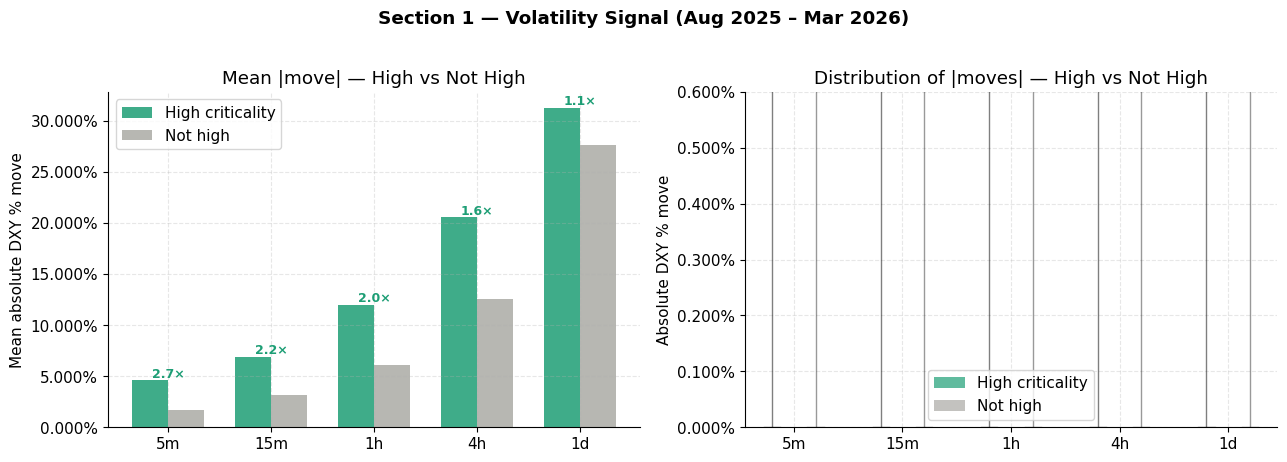

Saved: s1_volatility_signal.png


In [5]:
# ── Chart: mean |move| by horizon ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart mean abs move
ax = axes[0]
x   = np.arange(len(HORIZONS))
w   = 0.35
h_means  = [critical[h].abs().mean() for h in HORIZONS]
nh_means = [not_high[h].abs().mean() for h in HORIZONS]

ax.bar(x - w/2, h_means,  w, label='High criticality', color=TEAL,  alpha=0.85)
ax.bar(x + w/2, nh_means, w, label='Not high',         color=GRAY,  alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(H_LABELS)
ax.set_ylabel('Mean absolute DXY % move')
ax.set_title('Mean |move| — High vs Not High')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=3))

# Annotate lifts
for i, (hm, nhm) in enumerate(zip(h_means, nh_means)):
    ax.text(i, hm + 0.00005, f'{hm/nhm:.1f}×', ha='center', va='bottom', fontsize=9, color=TEAL, fontweight='bold')

# Right: box plot distributions
ax2 = axes[1]
data_h  = [critical[h].abs().dropna().values  for h in HORIZONS]
data_nh = [not_high[h].abs().dropna().values  for h in HORIZONS]

positions_h  = np.arange(len(HORIZONS)) * 2 - 0.4
positions_nh = np.arange(len(HORIZONS)) * 2 + 0.4

bp1 = ax2.boxplot(data_h,  positions=positions_h,  widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor=TEAL, alpha=0.6),
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='.', markersize=3, alpha=0.3),
                  whiskerprops=dict(alpha=0.5), capprops=dict(alpha=0.5))
bp2 = ax2.boxplot(data_nh, positions=positions_nh, widths=0.6, patch_artist=True,
                  boxprops=dict(facecolor=GRAY, alpha=0.4),
                  medianprops=dict(color='white', linewidth=2),
                  flierprops=dict(marker='.', markersize=3, alpha=0.2),
                  whiskerprops=dict(alpha=0.4), capprops=dict(alpha=0.4))

ax2.set_xticks(np.arange(len(HORIZONS)) * 2)
ax2.set_xticklabels(H_LABELS)
ax2.set_ylabel('Absolute DXY % move')
ax2.set_title('Distribution of |moves| — High vs Not High')
ax2.set_ylim(0, 0.006)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=3))

from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(facecolor=TEAL, alpha=0.7, label='High criticality'),
    Patch(facecolor=GRAY, alpha=0.5, label='Not high')
])

plt.suptitle('Section 1 — Volatility Signal (Aug 2025 – Mar 2026)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('s1_volatility_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s1_volatility_signal.png')

---
## 2. Directional Accuracy — Overall and Best Slices

In [6]:
# ── Define slices ─────────────────────────────────────────────────────────
slices = {
    'All critical':                   critical,
    'Tier 1 (Fed/Macro)':             critical[critical['event_tier'] == 1.0],
    'NFP / Jobs (events 10 & 11)':    critical[critical['event_number'].isin([10, 11])],
    'Table used':                     critical[critical['table_used'] == True],
    'Table + high confidence':        critical[(critical['table_used'] == True) &
                                               (critical['direction_confidence'] == 'high')],
    'Not high (baseline)':            not_high,
}

rows = []
for name, grp in slices.items():
    row = {'slice': name, 'n': len(grp)}
    for h, hl in zip(HORIZONS, H_LABELS):
        acc, n = dir_accuracy(grp, h)
        row[hl] = f'{acc*100:.1f}% ({n})' if n > 0 else 'n/a'
    rows.append(row)

acc_table = pd.DataFrame(rows).set_index('slice')
print('Directional accuracy by slice:')
display(acc_table)

Directional accuracy by slice:


,n,5m,15m,1h,4h,1d
slice,,,,,,
All critical,90,52.3% (86),53.5% (86),51.2% (84),48.8% (82),55.9% (59)
Tier 1 (Fed/Macro),67,56.1% (66),56.1% (66),45.3% (64),47.6% (63),50.0% (44)
NFP / Jobs (events 10 & 11),35,65.7% (35),68.6% (35),51.4% (35),48.5% (33),50.0% (18)
Table used,47,58.7% (46),60.9% (46),47.8% (46),47.7% (44),50.0% (26)
Table + high confidence,29,69.0% (29),58.6% (29),51.7% (29),46.4% (28),50.0% (18)
Not high (baseline),735,49.5% (279),48.4% (277),46.2% (275),49.4% (261),48.6% (218)


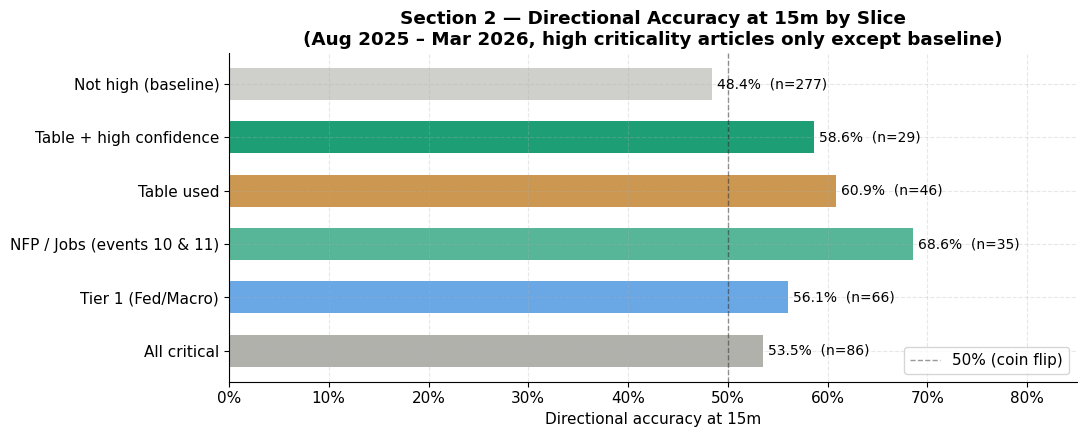

Saved: s2_direction_accuracy.png


In [7]:
# ── Chart: directional accuracy at 15m by slice ───────────────────────────
slice_names = list(slices.keys())
acc_15m = []
ns_15m  = []
for name, grp in slices.items():
    acc, n = dir_accuracy(grp, 'pct_15m')
    acc_15m.append(acc if not np.isnan(acc) else 0)
    ns_15m.append(n)

colors = [
    GRAY,   # all critical
    BLUE,   # tier 1
    TEAL,   # NFP
    AMBER,  # table used
    TEAL,   # table + high conf
    GRAY,   # not high baseline
]
alphas = [0.65, 0.75, 0.75, 0.75, 1.0, 0.4]

fig, ax = plt.subplots(figsize=(11, 4.5))
y_pos = np.arange(len(slice_names))
for i, (val, col, alp) in enumerate(zip([a * 100 for a in acc_15m], colors, alphas)):
    ax.barh(i, val, color=col, alpha=alp, height=0.6)

# Coin-flip reference
ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% (coin flip)')

# Annotate with accuracy + n
for i, (acc, n) in enumerate(zip(acc_15m, ns_15m)):
    ax.text(acc * 100 + 0.5, i, f'{acc*100:.1f}%  (n={n})', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(slice_names)
ax.set_xlabel('Directional accuracy at 15m')
ax.set_xlim(0, 85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Section 2 — Directional Accuracy at 15m by Slice\n(Aug 2025 – Mar 2026, high criticality articles only except baseline)',
             fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('s2_direction_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2_direction_accuracy.png')

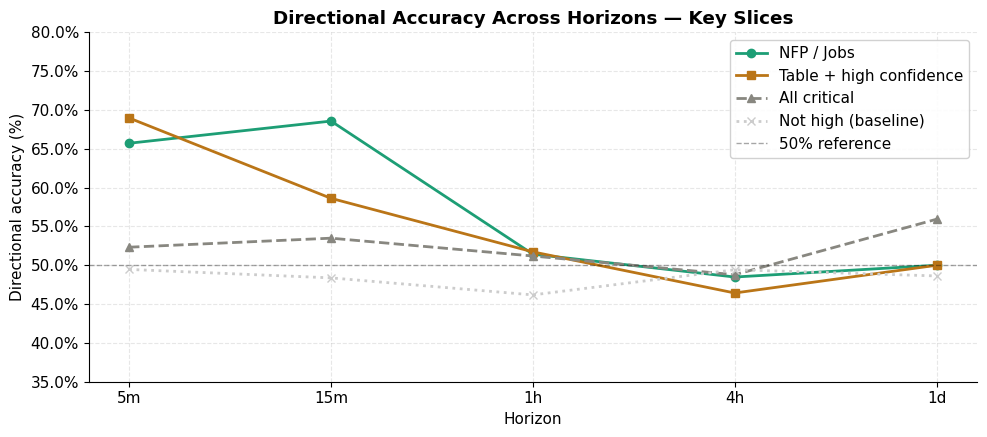

Saved: s2b_direction_by_horizon.png


In [8]:
# ── Direction accuracy across all horizons for key slices ─────────────────
key_slices = {
    'NFP / Jobs':              critical[critical['event_number'].isin([10, 11])],
    'Table + high confidence': critical[(critical['table_used'] == True) &
                                        (critical['direction_confidence'] == 'high')],
    'All critical':            critical,
    'Not high (baseline)':     not_high,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
slice_colors = [TEAL, AMBER, GRAY, '#cccccc']
slice_styles = ['-o', '-s', '--^', ':x']

for (name, grp), color, style in zip(key_slices.items(), slice_colors, slice_styles):
    accs = []
    ns   = []
    for h in HORIZONS:
        acc, n = dir_accuracy(grp, h)
        accs.append(acc * 100 if not np.isnan(acc) else np.nan)
        ns.append(n)
    ax.plot(H_LABELS, accs, style, color=color, label=name, linewidth=2, markersize=6)

ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.35, label='50% reference')
ax.set_ylabel('Directional accuracy (%)')
ax.set_xlabel('Horizon')
ax.set_ylim(35, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(framealpha=0.9)
ax.set_title('Directional Accuracy Across Horizons — Key Slices', fontweight='bold')
plt.tight_layout()
plt.savefig('s2b_direction_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s2b_direction_by_horizon.png')

In [9]:
# ── Direction confidence breakdown ────────────────────────────────────────
dir_crit = critical[critical['direction'].isin(['up','down'])].copy()

rows = []
for conf in ['high', 'medium']:
    sub = dir_crit[dir_crit['direction_confidence'] == conf]
    row = {'direction_confidence': conf, 'n': len(sub)}
    for h, hl in zip(['pct_5m','pct_15m','pct_1h'], ['5m','15m','1h']):
        acc, n = dir_accuracy(sub, h)
        row[hl] = f'{acc*100:.1f}%' if n > 0 else 'n/a'
    rows.append(row)

print('Direction accuracy by model confidence level (critical articles only):')
display(pd.DataFrame(rows).set_index('direction_confidence'))
print('\nNote: medium confidence outperforms high confidence at 15m — the model'
      '\nmay be overconfident on events where historical table data is absent.')

Direction accuracy by model confidence level (critical articles only):


,n,5m,15m,1h
direction_confidence,,,,
high,66,55.6%,50.8%,54.8%
medium,24,43.5%,60.9%,40.9%



Note: medium confidence outperforms high confidence at 15m — the model
may be overconfident on events where historical table data is absent.


---
## 3. Monthly Stability

In [10]:
# ── Monthly stats ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', 'Converting to PeriodArray')

critical['ym'] = critical['dt'].dt.to_period('M')

monthly_rows = []
for ym, grp in critical.groupby('ym'):
    acc15, n15 = dir_accuracy(grp, 'pct_15m')
    acc1h, n1h = dir_accuracy(grp, 'pct_1h')
    monthly_rows.append({
        'month':        str(ym),
        'n critical':   len(grp),
        '15m acc':      round(acc15 * 100, 1) if not np.isnan(acc15) else np.nan,
        '15m n':        n15,
        '1h acc':       round(acc1h * 100, 1) if not np.isnan(acc1h) else np.nan,
        'mean |15m|':   round(grp['pct_15m'].abs().mean() * 100, 4),
    })

monthly_df = pd.DataFrame(monthly_rows)
display(monthly_df.set_index('month'))

,n critical,15m acc,15m n,1h acc,mean |15m|
month,,,,,
2025-08,20,65.0,20,45.0,13.4369
2025-09,22,50.0,22,38.1,6.2012
2025-10,9,12.5,8,42.9,2.6538
2025-11,5,60.0,5,40.0,2.7961
2025-12,4,50.0,4,50.0,8.9059
2026-01,5,75.0,4,0.0,6.3177
2026-02,12,54.5,11,72.7,5.0393
2026-03,13,58.3,12,91.7,3.0342


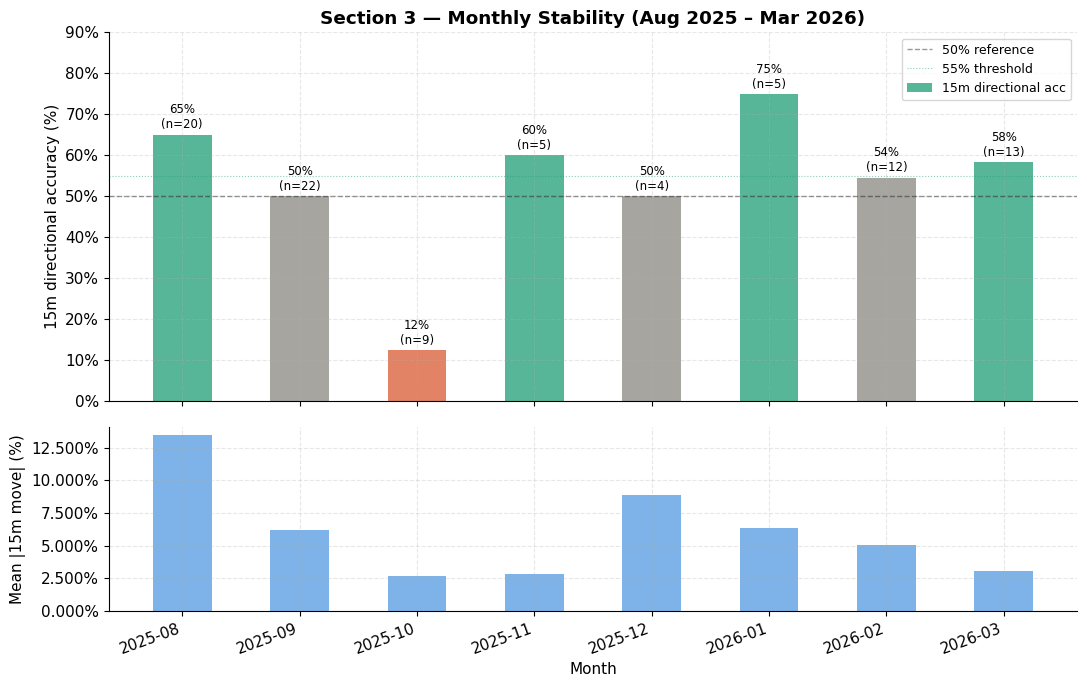

Saved: s3_monthly_stability.png


In [11]:
# ── Chart: monthly accuracy + volume ──────────────────────────────────────
months    = monthly_df['month'].tolist()
acc_vals  = monthly_df['15m acc'].tolist()
n_vals    = monthly_df['n critical'].tolist()
mean_abs  = monthly_df['mean |15m|'].tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: accuracy line
bar_colors = [TEAL if a >= 55 else CORAL if a < 45 else GRAY for a in acc_vals]
ax1.bar(months, acc_vals, color=bar_colors, alpha=0.75, width=0.5, label='15m directional acc')
ax1.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% reference')
ax1.axhline(55, color=TEAL,   linewidth=0.8, linestyle=':', alpha=0.5, label='55% threshold')

for i, (a, n) in enumerate(zip(acc_vals, n_vals)):
    if not np.isnan(a):
        ax1.text(i, a + 0.8, f'{a:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=8.5)

ax1.set_ylabel('15m directional accuracy (%)')
ax1.set_ylim(0, 90)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(loc='upper right', fontsize=9)
ax1.set_title('Section 3 — Monthly Stability (Aug 2025 – Mar 2026)', fontweight='bold')

# Bottom: mean absolute move
ax2.bar(months, mean_abs, color=BLUE, alpha=0.65, width=0.5)
ax2.set_ylabel('Mean |15m move| (%)')
ax2.set_xlabel('Month')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=3))

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('s3_monthly_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s3_monthly_stability.png')

---
## 4. SD-Capture: Does High Criticality Find the Biggest Moves?

In [12]:
# ── Moves ≥ 1SD and ≥ 2SD captured ───────────────────────────────────────
def sd_capture(subset, horizon, threshold):
    s = subset[subset['direction'].isin(['up','down']) & subset[horizon].notna()].copy()
    s['actual_dir'] = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    above = s[s[horizon].abs() >= threshold]
    hits  = (above['actual_dir'] == above['direction']).sum()
    return hits, len(above)

rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    h1, n1 = sd_capture(critical, h, sd[h])
    h2, n2 = sd_capture(critical, h, sd[h] * 2)
    rows.append({
        'horizon':    hl,
        '1SD thresh': f'{sd[h]*100:.4f}%',
        '≥1SD hits':  f'{h1}/{n1} = {h1/n1*100:.1f}%' if n1 else 'n/a',
        '2SD thresh': f'{sd[h]*2*100:.4f}%',
        '≥2SD hits':  f'{h2}/{n2} = {h2/n2*100:.1f}%' if n2 else 'n/a',
    })

print('SD-capture: directional accuracy on the largest moves\n(among critical articles where |actual move| ≥ 1SD or 2SD):')
display(pd.DataFrame(rows).set_index('horizon'))

SD-capture: directional accuracy on the largest moves
(among critical articles where |actual move| ≥ 1SD or 2SD):


,1SD thresh,≥1SD hits,2SD thresh,≥2SD hits
horizon,,,,
5m,4.1613%,8/18 = 44.4%,8.3226%,5/7 = 71.4%
15m,6.0817%,14/22 = 63.6%,12.1634%,7/9 = 77.8%
1h,11.0561%,12/21 = 57.1%,22.1123%,3/7 = 42.9%
4h,20.1538%,18/29 = 62.1%,40.3075%,8/9 = 88.9%
1d,35.4713%,14/21 = 66.7%,70.9425%,3/4 = 75.0%


In [13]:
# ── What fraction of all ≥1SD moves does the model capture? ───────────────
print('Coverage: what fraction of all ≥1SD moves did "high" criticality flag?\n')
rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    all_big    = df[df[h].abs() >= sd[h]]
    flagged    = critical[critical[h].abs() >= sd[h]]
    coverage   = len(flagged) / len(all_big) if len(all_big) else np.nan
    rows.append({
        'horizon':       hl,
        'all ≥1SD':      len(all_big),
        'flagged high':  len(flagged),
        'coverage':      f'{coverage*100:.1f}%' if not np.isnan(coverage) else 'n/a',
    })
display(pd.DataFrame(rows).set_index('horizon'))

Coverage: what fraction of all ≥1SD moves did "high" criticality flag?



,all ≥1SD,flagged high,coverage
horizon,,,
5m,94,18,19.1%
15m,168,22,13.1%
1h,187,21,11.2%
4h,211,29,13.7%
1d,270,21,7.8%


---
## 5. Summary — What to Take to the Presentation

In [14]:
# ── Headline numbers ──────────────────────────────────────────────────────
vol_lift_15m  = critical['pct_15m'].abs().mean() / not_high['pct_15m'].abs().mean()
_, p_15m      = mannwhitneyu(critical['pct_15m'].dropna().abs(),
                              not_high['pct_15m'].dropna().abs(), alternative='greater')
nfp_acc, nfp_n = dir_accuracy(critical[critical['event_number'].isin([10,11])], 'pct_15m')
best_acc, best_n = dir_accuracy(
    critical[(critical['table_used']==True) & (critical['direction_confidence']=='high')],
    'pct_5m')
overall_acc, overall_n = dir_accuracy(critical, 'pct_15m')

print('═' * 58)
print('  HEADLINE NUMBERS (Aug 2025 – Mar 2026, Apr/May excluded)')
print('═' * 58)
print(f'  Critical articles      : {len(critical)} of {len(relevant)} relevant ({len(critical)/len(relevant)*100:.1f}%)')
print()
print('  VOLATILITY SIGNAL')
print(f'  High criticality lift  : {vol_lift_15m:.2f}× at 15m vs not-high')
print(f'  Mann-Whitney p         : {p_15m:.4f}  (significant: {"yes" if p_15m < 0.05 else "no"})')
print()
print('  DIRECTIONAL ACCURACY AT 15m')
print(f'  All critical           : {overall_acc*100:.1f}%  (n={overall_n})')
print(f'  NFP / Jobs events      : {nfp_acc*100:.1f}%  (n={nfp_n})')
print(f'  Table + high confidence: {best_acc*100:.1f}%  at 5m  (n={best_n})')
print()
print('  BEST MONTH')
best_month = monthly_df.loc[monthly_df['15m acc'].idxmax()]
print(f'  {best_month["month"]}    : {best_month["15m acc"]}%  (n={best_month["n critical"]})')
print('═' * 58)

══════════════════════════════════════════════════════════
  HEADLINE NUMBERS (Aug 2025 – Mar 2026, Apr/May excluded)
══════════════════════════════════════════════════════════
  Critical articles      : 90 of 825 relevant (10.9%)

  VOLATILITY SIGNAL
  High criticality lift  : 2.18× at 15m vs not-high
  Mann-Whitney p         : 0.0099  (significant: yes)

  DIRECTIONAL ACCURACY AT 15m
  All critical           : 53.5%  (n=86)
  NFP / Jobs events      : 68.6%  (n=35)
  Table + high confidence: 69.0%  at 5m  (n=29)

  BEST MONTH
  2026-01    : 75.0%  (n=5)
══════════════════════════════════════════════════════════


In [15]:
df = pd.read_csv('data/results_cutoff_v2.csv')